In [1]:
import os
import sys
sys.path.append(r'../')
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import pandas as pd

from src.d_CSL import *
from src.dataload import *
from src.dataPreProcessing import replace_nan
from tqdm.notebook import tqdm

No GPU automatically detected. Setting SETTINGS.GPU to 0, and SETTINGS.NJOBS to cpu_count.


In [2]:
%reload_ext autoreload
%autoreload 2
from src.d_CSL import *

In [3]:
N_PASTS, n_lags, n_perm = list(range(2, 4)), 1, 1000
alpha, beta = 0.001, 0

In [4]:
def make_GT(name):
    start = name.find('.')
    gt_name = name[:start] + '_gt_processed.csv'
    dat = load_data(name)
    data = dat['ts'].T
    n = data.shape[0]

    df = pd.read_csv(gt_name, header=None)
    gt = df.values
    GT = np.zeros((n,n))
    for r in gt:
        GT[r[0], r[1]] = 1
    return GT.T

def mat_func(A, inf):
    return (40 * np.logical_and(A != 0, inf != 0) +
                30 * np.logical_and(A == 0, inf != 0) +
                20 * np.logical_and(A != 0, inf == 0) +
                10 * np.logical_and(A == 0, inf == 0))

names[0][:names[0].find('.')].replace('timeseries', '')

In [5]:
%%time

# load data
os.chdir(r'./data/fMRI_sims/')
names = [n for n in os.listdir() if n.endswith('.mat')]
INFs = {}
CONF_MTX = {}
SHDs = {}
METRICS = {}
for i in range(len(names)):
    print('Data ' + names[i])
    
    A = make_GT(names[i])
    X_ = load_data(names[i])
    X = X_['ts'].T
    
    # Analysis
    infs_fgc = []
    conf_mtx_fgc = []
    shds_fgc = []
    metrics_fgc = []
    for a, n in enumerate(N_PASTS):
        
        print(f'{n} pasts')
        gcstar = GcStar(n_perm = 1000, 
                    n_pasts = n, 
                    n_lags = n_lags,
                    temporal = True,
                    method = 'fcgc')
    
        gcstar.fit(X, verbose = 0)
        inf = gcstar.get_connectivity_matrix(alpha=alpha, beta=beta, simulation=False)   # 
        infs_fgc.append(inf)
        conf_mtx_fgc.append(gcstar.compute_confusion_matrix(A))
        metrics_fgc.append(gcstar.all_metrics())
        shds_fgc.append(gcstar.compute_shd_sid(A, inf))
    INFs[names[i]] = infs_fgc
    CONF_MTX[names[i]] = conf_mtx_fgc
    SHDs[names[i]] = shds_fgc
    METRICS[names[i]] = metrics_fgc
    print('')
    print('')



Data sim19.mat
2 pasts
3 pasts


Data sim25.mat
2 pasts
3 pasts


Data sim24.mat
2 pasts
3 pasts


Data sim18.mat
2 pasts
3 pasts


Data sim26.mat
2 pasts
3 pasts


Data sim9.mat
2 pasts
3 pasts


Data sim8.mat
2 pasts
3 pasts


Data sim27.mat
2 pasts
3 pasts


Data sim23.mat
2 pasts
3 pasts


Data sim22.mat
2 pasts
3 pasts


Data sim20.mat
2 pasts
3 pasts


Data sim21.mat
2 pasts
3 pasts


Data sim10.mat
2 pasts
3 pasts


Data sim3.mat
2 pasts
3 pasts


Data sim2.mat
2 pasts
3 pasts


Data sim11.mat
2 pasts
3 pasts


Data sim13.mat
2 pasts
3 pasts


Data sim1.mat
2 pasts
3 pasts


Data sim12.mat
2 pasts
3 pasts


Data sim16.mat
2 pasts
3 pasts


Data sim5.mat
2 pasts
3 pasts


Data sim4.mat
2 pasts
3 pasts


Data sim17.mat
2 pasts
3 pasts


Data sim15.mat
2 pasts
3 pasts


Data sim6.mat
2 pasts
3 pasts


Data sim7.mat
2 pasts
3 pasts


Data sim28.mat
2 pasts
3 pasts


Data sim14.mat
2 pasts
3 pasts


CPU times: user 3h 46min 12s, sys: 17min 4s, total: 4h 3min 16s
Wall time: 3h 10min 1

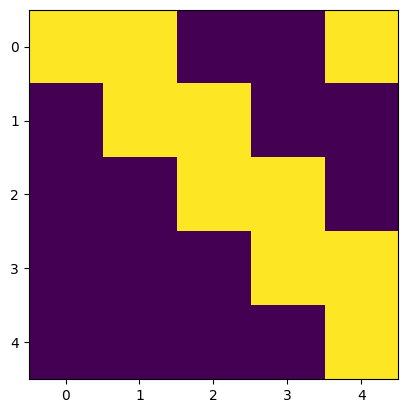

In [6]:
INFs
#plt.imshow(INFs['sim9.mat'])
plt.imshow(make_GT('sim9.mat'))

In [8]:
METRICS

{'sim19.mat': [array([0.4       , 0.4       , 1.        , 1.        , 0.5       ,
         0.57142857]),
  array([0.4       , 0.4       , 1.        , 1.        , 0.5       ,
         0.57142857])],
 'sim25.mat': [array([0.68      , 0.55555556, 1.        , 0.53333333, 0.73333333,
         0.71428571]),
  array([0.76      , 0.625     , 1.        , 0.4       , 0.8       ,
         0.76923077])],
 'sim24.mat': [array([0.4       , 0.4       , 1.        , 1.        , 0.5       ,
         0.57142857]),
  array([0.4       , 0.4       , 1.        , 1.        , 0.5       ,
         0.57142857])],
 'sim18.mat': [array([0.72      , 0.58823529, 1.        , 0.46666667, 0.76666667,
         0.74074074]),
  array([0.72      , 0.58823529, 1.        , 0.46666667, 0.76666667,
         0.74074074])],
 'sim26.mat': [array([0.76      , 0.625     , 1.        , 0.4       , 0.8       ,
         0.76923077]),
  array([0.72      , 0.58823529, 1.        , 0.46666667, 0.76666667,
         0.74074074])],
 'sim9.mat

In [ ]:
for i in range(28):
  A = make_GT(names[i])
  fig,ax = plt.subplots(1,2,figsize=(10,4))
  for j in range(2):
    ax[j].imshow(mat_func(A, INFs[names[i]][j]))
    ax[j].set_title(f'{j+5} pasts')
    ax[j].grid()
  plt.suptitle(f'Data {names[i]}', fontsize=18)
plt.tight_layout()

In [ ]:
SHDs

In [ ]:
stop

# On timeseries datas

In [ ]:
def make_GT(name):
    dat = pd.read_csv(name,header=0)   # load_data(name)
    data = dat.values.T # dat['ts'].T
    n = data.shape[0]
    
    gt_name = 'sim' + names[i][:names[i].find('.')].replace('timeseries', '') + '_gt_processed.csv'
    #start = name.find('.')
    #gt_name =          #name[:start] + '_gt_processed.csv'
    

    df = pd.read_csv(gt_name, header=None)
    gt = df.values
    GT = np.zeros((n,n))
    for r in gt:
        GT[r[0], r[1]] = 1
    return GT.T

def mat_func(A, inf):
    return (40 * np.logical_and(A != 0, inf != 0) +
                30 * np.logical_and(A == 0, inf != 0) +
                20 * np.logical_and(A != 0, inf == 0) +
                10 * np.logical_and(A == 0, inf == 0))

In [ ]:
%%time

# load data
#os.chdir(r'./data/fMRI_sims/')
names = [n for n in os.listdir() if n.endswith('.csv') and '_gt_' not in n]
INFs_new = {}
CONF_MTX_new = {}
SHDs_new = {}
METRICS_new = {}
# CONF_MTX = {}
for i in range(len(names)):
    
    # A = make_GT(names[i])
    X_ = pd.read_csv(names[i], header=0)
    X = X_.values.T
    
    print('Data ' + names[i] + ' with len = {}'.format(X.shape[1]))
    print('')
    # Analysis
    infs = []
    # conf_mtx = []
    for a, n in enumerate(N_PASTS):
        
        print(f'{n} pasts')
        gcstar = GcStar(n_perm = 1000, 
                    n_pasts = n, 
                    n_lags = n_lags,
                    temporal = True,
                    method = 'fcgc')
    
        gcstar.fit(X, verbose = 0)
        inf = gcstar.get_connectivity_matrix(alpha=alpha, beta=beta, simulation=False)   # 
        infs_fgc.append(inf)
        conf_mtx_fgc.append(gcstar.compute_confusion_matrix(A))
        metrics_fgc.append(gcstar.all_metrics())
        shds_fgc.append(gcstar.compute_shd_sid(A, inf))
    INFs_new[names[i]] = infs_fgc
    CONF_MTX_new[names[i]] = conf_mtx_fgc
    SHDs_new[names[i]] = shds_fgc
    METRICS_new[names[i]] = metrics_fgc
    print('')
    print('')

In [ ]:
stop

In [ ]:
#names = [n for n in os.listdir() if n.endswith('.csv') and 'timeseries' in n]
GTs = {}
for i in range(len(names)):
    GTs[names[i]] = make_GT(names[i])
    plt.figure()
    plt.imshow(make_GT(names[i]))

In [ ]:
for i in range(28):
  A = make_GT(names[i])
  fig,ax = plt.subplots(1,2,figsize=(10,4))
  for j in range(2):
    ax[j].imshow(mat_func(A, INFs[names[i]][j]))
    ax[j].set_title(f'{j+5} pasts')
    ax[j].grid()
  plt.suptitle(f'Data {names[i]}', fontsize=18)
plt.tight_layout()

In [ ]:
INFs_new

In [ ]:
METs_new

# Selections

In [ ]:
N_PASTS, n_lags, n_perm = list(range(3, 10)), 1, 1000

In [ ]:
%%time

# load data
#os.chdir(r'./data/fMRI_sims/')
names = ['timeseries19.csv', 'timeseries20.csv', 'timeseries5.csv', 'timeseries6.csv', 'timeseries7.csv', 'timeseries9.csv']
INFs_new = {}
# CONF_MTX = {}
for i in range(len(names)):
    
    # A = make_GT(names[i])
    X_ = pd.read_csv(names[i], header=0)
    X = X_.values.T
    
    print('Data ' + names[i] + ' with len = {}'.format(X.shape[1]))
    print('')
    # Analysis
    infs = []
    # conf_mtx = []
    for a, n in enumerate(N_PASTS):
        
        print(f'{n} pasts')
        gcstar = GcStar(n_perm = 1000, 
                    n_pasts = n, 
                    n_lags = n_lags,
                    temporal = True,
                    method = 'fcgc')
    
        gcstar.fit(X, verbose = 0)
        inf = gcstar.get_connectivity_matrix(alpha=0.001, beta=0, simulation=True)   # 
        infs.append(inf)
        #conf = gcstar.compute_confusion_matrix(A)
        #conf_mtx.append(conf)
        
    INFs_new[names[i]] = infs
    #CONF_MTX[names[i]] = conf_mtx
    print('')
    print('')

In [ ]:
#names = [n for n in os.listdir() if n.endswith('.csv') and 'timeseries' in n]
GTs = {}
for i in range(len(names)):
    GTs[names[i]] = make_GT(names[i])
    plt.figure()
    plt.imshow(make_GT(names[i]))

In [ ]:
print(INFs_new.keys())

In [ ]:
INFs_new

In [ ]:
CONFs_new = {}
METs_new = {}
for i, keys in enumerate(INFs_new):  
    gt = GTs[keys]
    confs, mets = [], []
    fig,ax = plt.subplots(1,7,figsize=(20,4))
    for j in range(7):
        c = confusion_matrix(INFs_new[keys][j], gt)
        confs.append(c)
        mets.append(apr_metrics(c))
        
        
        ax[j].imshow(mat_func(gt, INFs_new[keys][j]))
        ax[j].set_title(f'{j+3} pasts')
        ax[j].grid()
    plt.suptitle(f'Data {names[i]}', fontsize=18)
    
    CONFs_new[keys], METs_new[keys] = confs, mets
plt.tight_layout()

In [ ]:
METs_new

In [ ]:
for key in METs_new:
    print(f'mean = {np.mean(METs_new[key], axis=0)}')
    print(f'std = {np.std(METs_new[key], axis=0)}')  
    print('')